In [49]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
le=LabelEncoder()


In [8]:
df=pd.read_csv("salary_prediction.csv")

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   experience  29 non-null     str  
 1   education   29 non-null     str  
 2   city        28 non-null     str  
 3   age         29 non-null     str  
 4   salary      29 non-null     str  
dtypes: str(5)
memory usage: 1.3 KB


In [10]:
df.isnull().sum()

experience    1
education     1
city          2
age           1
salary        1
dtype: int64

In [11]:
df["experience"]=pd.to_numeric(df["experience"],errors="coerce")
df["age"]=pd.to_numeric(df["age"],errors="coerce")
df["salary"]=pd.to_numeric(df["salary"],errors="coerce")

In [12]:
df["experience"]=df["experience"].fillna(df["experience"].mean())
df["age"]=df["age"].fillna(df["age"].mean())
df["salary"]=df["salary"].fillna(df["salary"].mean())
df["city"]=df["city"].fillna("unknown")
df["salary"]=df["salary"].fillna(df["salary"].median())
df["education"]=df["education"].fillna(df["education"].mode()[0])

In [13]:
df.isnull().sum()

experience    0
education     0
city          0
age           0
salary        0
dtype: int64

In [14]:
df

,experience,education,city,age,salary
0,2.000000,Bachelors,Chennai,23.000000,25000.000000
1,5.000000,Masters,Bangalore,28.000000,45000.000000
2,3.000000,Bachelors,Salem,25.000000,30000.000000
3,10.000000,PhD,Hyderabad,35.000000,90000.000000
4,1.000000,Bachelors,unknown,22.000000,20000.000000
5,7.000000,Masters,Chennai,30.000000,60000.000000
6,4.000000,Bachelors,Coimbatore,27.000000,35000.000000
7,4.888889,Bachelors,Madurai,26.000000,32000.000000
8,8.000000,Masters,Bangalore,31.000000,70000.000000
9,4.888889,PhD,Chennai,40.000000,100000.000000


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   experience  30 non-null     float64
 1   education   30 non-null     str    
 2   city        30 non-null     str    
 3   age         30 non-null     float64
 4   salary      30 non-null     float64
dtypes: float64(3), str(2)
memory usage: 1.3 KB


In [16]:
df["education"]=df["education"].str.strip()
df["education"]=df["education"].str.lower()
df["city"]=df["city"].str.strip()
df["city"]=df["city"].str.lower()



In [17]:
df["age"]=df["age"].astype(int)
df["experience"]=df["experience"].astype(int)
df["salary"]=df["salary"].astype(int)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   experience  30 non-null     int64
 1   education   30 non-null     str  
 2   city        30 non-null     str  
 3   age         30 non-null     int64
 4   salary      30 non-null     int64
dtypes: int64(3), str(2)
memory usage: 1.3 KB


In [19]:
df

,experience,education,city,age,salary
0,2,bachelors,chennai,23,25000
1,5,masters,bangalore,28,45000
2,3,bachelors,salem,25,30000
3,10,phd,hyderabad,35,90000
4,1,bachelors,unknown,22,20000
5,7,masters,chennai,30,60000
6,4,bachelors,coimbatore,27,35000
7,4,bachelors,madurai,26,32000
8,8,masters,bangalore,31,70000
9,4,phd,chennai,40,100000


In [20]:
df.columns

Index(['experience', 'education', 'city', 'age', 'salary'], dtype='str')

In [21]:
df=pd.get_dummies(df,columns=["education","city"])

In [22]:
df.columns

Index(['experience', 'age', 'salary', 'education_bachelors',
       'education_masters', 'education_phd', 'city_bangalore', 'city_chennai',
       'city_coimbatore', 'city_hyderabad', 'city_madurai', 'city_salem',
       'city_trichy', 'city_unknown'],
      dtype='str')

In [23]:
x= df.drop("salary",axis=1)

In [26]:
y=df["salary"]

In [34]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2)

In [38]:
model=LinearRegression()

In [39]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
y_pred=model.predict(x_test)

In [46]:
accuracy=r2_score(y_test,y_pred)
print("r2_score:" ,accuracy)

r2_score: 0.9655748198187329


In [48]:
new_data = [[5, 30, 1, 0, 0, 0,1,0,0,0,0,0,0]]
predicted_salary = model.predict(new_data)

print(predicted_salary)

[45958.97222378]


C:\Ai vscode\Data Exploration Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


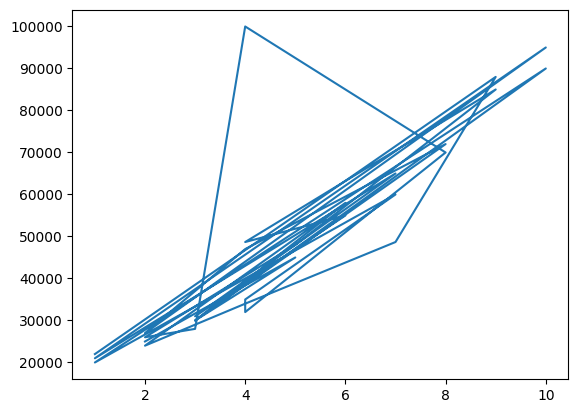

In [54]:
plt.plot(df["experience"],df["salary"])
plt.show()

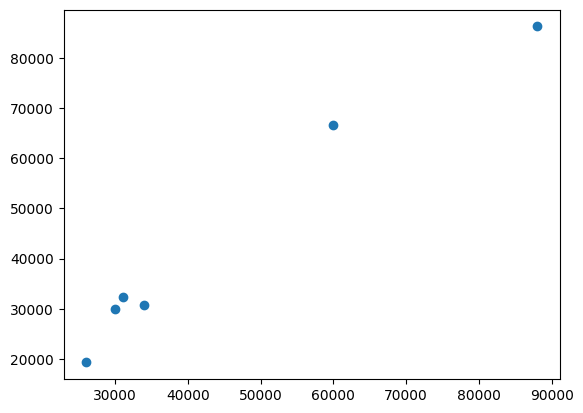

In [57]:
plt.scatter(y_test, y_pred)
plt.show()